In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Torch codec fix
import os, sys
npp_path = f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages/nvidia/cu13/lib"
os.environ["LD_LIBRARY_PATH"] = f"{npp_path}:{os.environ.get('LD_LIBRARY_PATH', '')}"
print("LD_LIBRARY_PATH set to:", os.environ["LD_LIBRARY_PATH"])

import ctypes, sys
libdir = f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages/nvidia/cu13/lib"
for so in ("libnppc.so.13", "libnppig.so.13", "libnppicc.so.13"):
    ctypes.CDLL(f"{libdir}/{so}", mode=ctypes.RTLD_GLOBAL)
print("Preloaded NPP libs from:", libdir)

LD_LIBRARY_PATH set to: /home/ubuntu/diffusion/venv/lib/python3.10/site-packages/nvidia/cu13/lib:/home/ubuntu/diffusion/venv/lib/python3.10/site-packages/nvidia/cu13/lib:/usr/mpi/gcc/openmpi-4.1.7rc1/lib:/usr/mpi/gcc/openmpi-4.1.7rc1/lib64
Preloaded NPP libs from: /home/ubuntu/diffusion/venv/lib/python3.10/site-packages/nvidia/cu13/lib


In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset
from torchcodec.decoders import VideoDecoder

In [10]:
class CSDataset(Dataset):
    def __init__(self, data_path, split="train", T=30, stride=1):
        self.data_path = Path(data_path)
        self.T = T
        self.stride = stride

        with open(self.data_path / "manifest.json", "r", encoding="utf-8") as f:
            manifest = json.load(f)

        self.samples = [m for m in manifest if m["split"] == split]

        # Build per-clip window counts
        total = 0
        for s in self.samples:
            # Prefer manifest frames if present
            n_frames = int(s.get("frames", 0))
            if n_frames <= 0:
                # fallback from ticks
                tick_rate = int(s.get("tick_rate", 64))
                fps = int(s.get("fps", 30))
                ticks = int(s["end_tick"]) - int(s["start_tick"])
                n_frames = int(round(ticks / tick_rate * fps))

            windows = max(0, n_frames - (self.T - 1) * self.stride)
            s["num_frames"] = n_frames
            s["windows"] = windows
            total += windows

        self.total_windows = total
        self.prefixes = np.cumsum([s["windows"] for s in self.samples], dtype=np.int64)

    def __len__(self):
        return int(self.total_windows)

    def __getitem__(self, global_idx):
        if global_idx < 0 or global_idx >= self.total_windows:
            raise IndexError(global_idx)

        # 1) global -> clip
        clip_idx = int(np.searchsorted(self.prefixes, global_idx, side="right"))
        clip = self.samples[clip_idx]
        prev = 0 if clip_idx == 0 else int(self.prefixes[clip_idx - 1])

        # 2) local window
        local_start = int(global_idx - prev)
        frame_ids = list(range(local_start, local_start + self.T * self.stride, self.stride))

        # 3) decode video frames with torchcodec
        video_path = self.data_path / clip["video_path"]   # e.g. videos/...
        decoder = VideoDecoder(str(video_path))
        fb = decoder.get_frames_at(indices=frame_ids)  # uint8 [T,C,H,W]
        frames = fb.data.float() / 127.5 - 1.0  # [T,C,H,W] in [-1,1]

        # 4) load aligned actions and slice same temporal window
        actions_path = self.data_path / clip["actions_path"]  # e.g. actions/...
        actions_df = pd.read_parquet(actions_path)
        
        #Mapping from the actions_df column names
        button_cols = ["FORWARD","LEFT","RIGHT","BACK","FIRE","RIGHTCLICK","RELOAD","INSPECT"]
        mouse_cols  = ["delta_pitch","delta_yaw"]   # optionally add pitch,yaw

        act = actions_df.set_index("frame_idx").reindex(frame_ids).fillna(0.0)
        act[button_cols] = act[button_cols].fillna(False).astype(np.float32)
        act[mouse_cols]  = act[mouse_cols].fillna(0.0).astype(np.float32)

        buttons = torch.tensor(act[button_cols].to_numpy(), dtype=torch.float32)  # [T,8]
        mouse   = torch.tensor(act[mouse_cols].to_numpy(), dtype=torch.float32)
        actions = torch.cat([buttons, mouse], dim=-1)  # [T,10]

        return {
            "video": frames,               # [T,C,H,W]
            "actions": actions,            # [T,A]
            "clip_idx": clip_idx,
            "start_frame": local_start,
            "meta": {
                "match_id": clip["match_id"],
                "player_id": clip["player_id"],
                "clip_id": clip["clip_id"],
            },
        }

In [11]:
DATA_PATH = "/home/ubuntu/diffusion/data"
dataset = CSDataset(DATA_PATH, split='train', T=300, stride=1)

print(f'Dataset length: {len(dataset)}')
print(f'Training hours: {((len(dataset)/30)/60)/60} hours')

test_sample = dataset[40]

Dataset length: 98425
Training hours: 0.9113425925925926 hours


torch.Size([300, 3, 720, 1280])


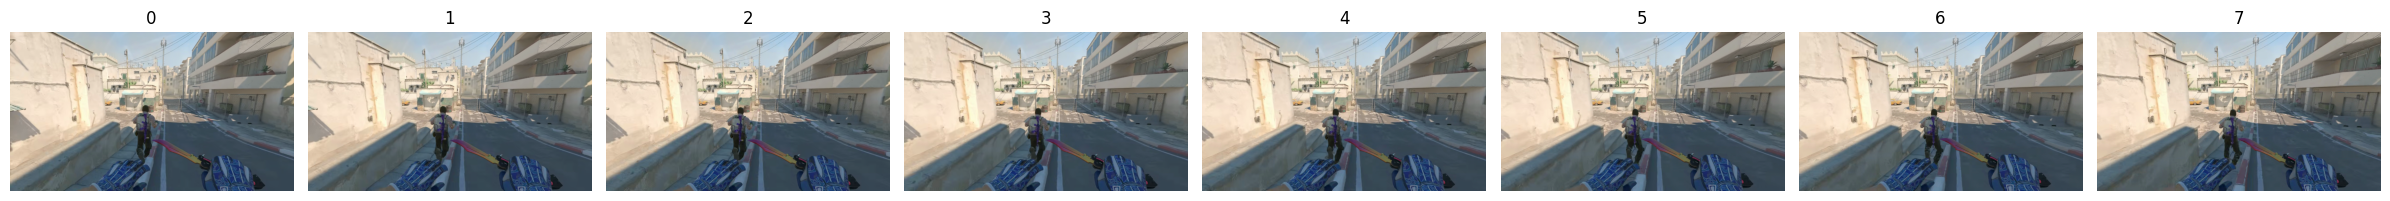

In [12]:
import matplotlib.pyplot as plt

video = test_sample['video']
print(video.shape) #30, 3, 720, 1280

n = min(8, video.shape[0])
fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
for i in range(n):
    img = video[i].permute(1, 2, 0).cpu() #H, W, C
    img = ((img + 1.0)/2.0).clamp(0,1)
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{i}")

plt.tight_layout()
plt.show()

In [1]:
import sys
sys.path.insert(0, "..")
from src.cs2_video_renderer import CS2VideoRenderer
from IPython.display import Image as IPyImage, display

renderer = CS2VideoRenderer()

sample = dataset[6500]  # or any sample
gif_path = renderer.render_gif_from_sample(
    frames_tchw=sample["video"],
    aligned_button_events=sample["actions"],
    fps=10,
    output_path="debug/debug_overlay.gif",
)

display(IPyImage(filename=gif_path))

NameError: name 'dataset' is not defined